# RQ2 analysis template: from profiling traces to CBS budgets

Copy this notebook next to a new workload's `results/` folder, edit **only the configuration cell** (section 0) and run all cells from top to bottom.
Every cell produces one table or one figure. The procedure:

| # | Step | Result |
|---|---|---|
| 1 | Stress profiling | C and W statistics per condition |
| 2 | Tail estimation | block maxima, GEV fit, platform-event check, bounds C_p |
| 3 | α_drift | spread of the baseline bounds over runs and VMs of the same type |
| 4 | α_cores | stressed / baseline bound on a second VM, rule for m |
| 5 | Budgets | Route 1, Route 2b, HWM, admission, risk curves, check on the second VM |
| 6 | p_floor | stalls and late jobs that no budget removes |
| 7 | Offline replay | held-out baselines, burst check on stressed traces |
| 8 | Online validation | KubeDeadline runs, pass rule, stalls, over-budgeting, tail growth |

**Data layout expected** (one CSV per instance, columns `instance_id, job_id, frame_idx, release_ns, start_ns, end_ns, cpu_ns, response_ns, wait_ns, lateness_ns, deadline_met, skipped, warmup`, plus `<instance>.meta.json`):

- `results/<scenario>/<condition>/<instance>.csv`: profiling session (baselines and stress conditions)
- `alpha_drift/results/<vm>/<scenario>/baseline/` and `.../<STRESS_COND>/`: runs on other VMs
- `validation/results/<scenario>/<route>/<p tag>_<interference>/`: online validation (only for section 8)

**Notation.** C = CPU time of a job (`cpu_ns`), W = dispatch latency (`start_ns − release_ns`), T = period = deadline, Q = budget, p = per-job miss tolerance, C_p = (1−p) quantile bound of C.

## 0. Configuration and helpers

In [1]:
from pathlib import Path
import json, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, gumbel_r, chi2, binom, beta

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", "{:.3f}".format)

# ======================== EDIT HERE FOR A NEW WORKLOAD ========================
RQ2 = Path("..")                                                       # folder that holds results/, alpha_drift/, validation/
SCENARIOS  = {"single_core": ["instance0"], "multi_core": ["instance0", "instance1"]}   # scenario -> instances
CONDITIONS = ["baseline1", "cache", "memory", "baseline2"]             # profiling conditions
BASELINES, STRESS = ["baseline1", "baseline2"], ["cache", "memory"]
P_LIST, TEST_P = [1e-1, 1e-2, 1e-3], [1e-2, 1e-3]                      # tolerances; TEST_P = the ones used in the pass tests

S1_VM      = {"single_core": "worker6", "multi_core": "worker7"}       # VM of the profiling session, per scenario
TEST_VM    = {"single_core": "worker7", "multi_core": "worker6"}       # second VM (same type), per scenario
DRIFT_VMS  = ["worker6", "worker7"]                                    # VMs that have a baseline in alpha_drift/results/<vm>/<scenario>/baseline
EXCLUDE_VMS = ("worker0",)                                             # other VM type (SMT): kept out of every drift pool
STRESS_COND = "memory"                                                 # stressor used on the test VM

ALPHA_PLATFORM = {1: 1.03, 2: 1.06, 3: 1.11}                           # alpha_cores,platform(m), m = number of enemy cores
M_USED = {"single_core": 3, "multi_core": 2}                           # decision per scenario (see section 4)
ADMISSION_MAX = 0.95                                                   # driver admission threshold Q/T
HWM_STRESS, HWM_MARGIN, HWM_P = ("cache", "memory"), 0.96, 1e-3        # third route: runs whose maximum is taken, accounting margin, p of alpha_drift
K_LIST = [10, 100]                                                     # window lengths of the worst-case (m,k)

BLOCK, P_GEV, RUNS_R = 600, 1e-3, 50          # block size (jobs) for block maxima, GEV only at p <= P_GEV, runs-method gap for clusters
L_BOOT, N_BOOT, ALPHA = 600, 300, 0.05        # moving-block bootstrap: block length, replicates, one-sided 95% upper bound
THR_MS = 1.0                                  # residual above this (ms) = candidate platform event
W_THRESH_MS = 5                               # a dispatch latency above this counts as "large"
JOBS_VALIDATION = 50000                       # jobs per online validation run
VAL_ROUTES = ("route1", "route2b")            # online validation folders
VAL_P = {"p1e-1": 0.1, "p1e-2": 0.01, "p1e-3": 0.001}
ACCOUNTING_MARGIN = 0.96                      # jobs are not late below this x Q* (measured online); stall classification only
# ==============================================================================

S1, S2, VAL = RQ2 / "results", RQ2 / "alpha_drift" / "results", RQ2 / "validation" / "results"
_meta = json.load(open(S1 / next(iter(SCENARIOS)) / CONDITIONS[0] / "instance0.meta.json"))
T_MS = float(_meta["args"]["period_ms"])                              # period = deadline, read from the run
print(f"period T = {T_MS} ms; scenarios: { {s: len(i) for s, i in SCENARIOS.items()} } instance(s)")

period T = 41.667 ms; scenarios: {'single_core': 1, 'multi_core': 2} instance(s)


In [2]:
rng = np.random.default_rng(0)

def load_series(path):
    """CPU time C (ms) of the executed jobs of one run, in job order (warm-up and skipped jobs dropped)"""
    df = pd.read_csv(path, usecols=["job_id", "skipped", "warmup", "cpu_ns"])
    df = df[(df.skipped == 0) & (df.warmup == 0)].sort_values("job_id")
    return (df.cpu_ns / 1e6).to_numpy()

def block_maxima(x, b=BLOCK):
    k = len(x) // b
    return x[: k * b].reshape(k, b).max(axis=1)

def boot_dist(x, ps=P_LIST, L=L_BOOT, B=N_BOOT):
    """moving-block bootstrap distribution of the (1-p) quantiles, shape (B, len(ps))"""
    qs, n = 1 - np.asarray(ps), len(x)
    k, ar = n // L, np.arange(L)
    out = np.empty((B, len(ps)))
    for i in range(B):
        starts = rng.integers(0, n - L + 1, size=k)
        out[i] = np.quantile(x[(starts[:, None] + ar).ravel()], qs)
    return out

def empirical_bound(x, ps, L=L_BOOT):
    """point (1-p) quantile and its upper 95% bound (moving-block bootstrap, keeps temporal dependence)"""
    return np.quantile(x, 1 - np.asarray(ps)), np.quantile(boot_dist(x, ps, L), 1 - ALPHA, axis=0)

def extremal_index(x, p, r=RUNS_R):
    """runs estimator: clusters of exceedances of the (1-p) quantile / exceedances"""
    idx = np.flatnonzero(x > np.quantile(x, 1 - p))
    return (1 + np.sum(np.diff(idx) > r)) / len(idx) if len(idx) else np.nan

def gev_theta(x, p, b, theta):
    """GEV bound of the per-job (1-p) level from block maxima, with extremal index; shape xi; LR test Gumbel vs GEV"""
    mx = block_maxima(x, b)
    c, loc, scale = genextreme.fit(mx)
    bound = genextreme.ppf((1 - p) ** (b * theta), c, loc, scale)
    lg, sg = gumbel_r.fit(mx)
    lr = 2 * (genextreme.logpdf(mx, c, loc, scale).sum() - gumbel_r.logpdf(mx, lg, sg).sum())
    return bound, -c, chi2.sf(lr, 1)

def exceed_test(x, C, p, r=RUNS_R):
    """cluster-aware test that C is a valid (1-p) bound: (exceedances, clusters, expected clusters, p-value)"""
    pos = np.flatnonzero(x > C)
    kc = (1 + int(np.sum(np.diff(pos) > r))) if len(pos) else 0
    n_eff = max(int(round(len(x) * extremal_index(x, p, r))), 1)
    return len(pos), kc, n_eff * p, (binom.sf(kc - 1, n_eff, p) if kc else 1.0)

def cp_upper(k, n, conf=0.95):
    """one-sided Clopper-Pearson upper bound for k events in n trials"""
    if n == 0:
        return np.nan
    return 1 - (1 - conf) ** (1 / n) if k == 0 else beta.ppf(conf, k + 1, n - k)

def overlap_mask(sa, ea, sb, eb):
    """for each interval [sa, ea]: does any interval [sb, eb] overlap it?"""
    out = np.zeros(len(sa), dtype=bool)
    if len(sa) == 0 or len(sb) == 0:
        return out
    o = np.argsort(sb)
    sb, eb = sb[o], eb[o]
    pm = np.maximum.accumulate(eb)                      # latest end among the intervals that start first
    hi = np.searchsorted(sb, ea, side="right")          # intervals of B that start before A ends
    ok = hi > 0
    out[ok] = pm[hi[ok] - 1] >= sa[ok]
    return out

def mk_worst(miss, k):
    """minimum number of MET deadlines in any window of k consecutive jobs"""
    if len(miss) < k:
        return np.nan
    return int(np.convolve((~miss).astype(np.int64), np.ones(k, dtype=np.int64), mode="valid").min())

def max_consecutive(miss):
    if not miss.any():
        return 0
    e = np.diff(np.concatenate(([0], miss.astype(np.int8), [0])))
    return int((np.flatnonzero(e == -1) - np.flatnonzero(e == 1)).max())

def replay(x, q, p):
    """miss model C > Q on a trace"""
    miss = x > q
    out = dict(miss_rate=miss.mean(), miss_over_p=miss.mean() / p, max_consec=max_consecutive(miss))
    for k in K_LIST:
        out[f"mk_worst_k{k}"] = mk_worst(miss, k)
    return out

## 1. Stress profiling

The workload runs without stress, under the cache enemy, under the memory enemy, and once more without stress.
Skipped activations have no timestamps and are not in the statistics (their count is in the table).
**Reading the table:** the last two rows are the stress effect in % against the mean of the baselines. A large effect at `max` and a small one at `p50` means the stress only touches the tail.

In [3]:
frames = []
for scen, insts in SCENARIOS.items():
    for cond in CONDITIONS:
        for inst in insts:
            df = pd.read_csv(S1 / scen / cond / f"{inst}.csv")
            df["scenario"], df["condition"] = scen, cond
            frames.append(df)
raw = pd.concat(frames, ignore_index=True)
skipped = raw.groupby(["scenario", "condition"], sort=False).skipped.sum()

data = raw[(raw.skipped == 0) & (raw.warmup == 0)].copy()
data["C_ms"] = data.cpu_ns / 1e6
data["W_us"] = (data.start_ns - data.release_ns) / 1e3
data = data.sort_values(["scenario", "condition", "instance_id", "job_id"]).reset_index(drop=True)
s1_series = {k: g.C_ms.to_numpy() for k, g in data.groupby(["scenario", "condition", "instance_id"])}   # C per profiling run

STAT = {"p50": .5, "p99": .99, "p99.9": .999, "max": 1.0}
for scen in SCENARIOS:
    d = data[data.scenario == scen]
    t = d.groupby("condition").C_ms.quantile(list(STAT.values())).unstack().set_axis([f"C {k} (ms)" for k in STAT], axis=1)
    t["W p50 (µs)"] = d.groupby("condition").W_us.median()
    t["W max (ms)"] = d.groupby("condition").W_us.max() / 1e3
    t[f"W > {W_THRESH_MS} ms"] = d.groupby("condition").W_us.agg(lambda w: int((w > W_THRESH_MS * 1e3).sum()))
    t["skipped"] = skipped[scen]
    t = t.loc[CONDITIONS]
    cols = [c for c in t.columns if c.startswith("C ")]
    for s in STRESS:
        t.loc[f"{s} vs baselines (%)", cols] = (t.loc[s, cols] / t.loc[BASELINES, cols].mean() - 1) * 100
    print(f"--- {scen} (instances pooled) ---")
    display(t.round(2).fillna(""))

--- single_core (instances pooled) ---


,C p50 (ms),C p99 (ms),C p99.9 (ms),C max (ms),W p50 (µs),W max (ms),W > 5 ms,skipped
condition,,,,,,,,
baseline1,15.000,22.300,22.810,25.420,195.180,16.130,13.000,0.000
cache,15.390,22.650,23.130,26.000,199.480,976.390,13.000,56.000
memory,15.520,22.910,23.460,32.330,197.850,24.250,7.000,0.000
baseline2,15.150,22.490,22.920,23.570,192.290,17.140,5.000,0.000
cache vs baselines (%),2.110,1.140,1.170,6.150,,,,
memory vs baselines (%),2.940,2.300,2.600,31.980,,,,


--- multi_core (instances pooled) ---


,C p50 (ms),C p99 (ms),C p99.9 (ms),C max (ms),W p50 (µs),W max (ms),W > 5 ms,skipped
condition,,,,,,,,
baseline1,14.920,22.050,22.450,26.360,200.660,2943.050,35.000,142.000
cache,15.050,22.180,22.640,25.760,199.950,22.500,36.000,0.000
memory,14.710,21.840,22.270,22.920,194.000,21.080,31.000,0.000
baseline2,14.340,21.440,21.880,24.620,192.180,37.650,32.000,2.000
cache vs baselines (%),2.920,2.020,2.150,1.070,,,,
memory vs baselines (%),0.570,0.460,0.440,-10.070,,,,


## 2. Tail estimation

### 2.1 Block maxima and GEV fit
The trace is cut into blocks of `BLOCK` jobs, the maximum of each block is fitted with a GEV (shape ξ; scipy's `c = −ξ`), instances pooled.
**Reading the table:** ξ < 0 is a bounded tail and `upper end` is the fitted upper end point; ξ ≥ 0 has no upper end. `max block` is the largest observed block maximum.

In [4]:
bm = {(s, c): np.concatenate([block_maxima(s1_series[(s, c, i)]) for i in SCENARIOS[s]]) for s in SCENARIOS for c in CONDITIONS}
rows = []
for (s, c), x in bm.items():
    cc, loc, scale = genextreme.fit(x)
    rows.append(dict(scenario=s, condition=c, n_blocks=len(x), xi=-cc, loc=loc, scale=scale,
                     **{"upper end": loc + scale / cc if cc > 0 else np.nan}, **{"max block": x.max()}))
fits = pd.DataFrame(rows).set_index(["scenario", "condition"])
display(fits.round(3))

n_blocks     xi    loc  scale  upper end  max block
scenario    condition                                                     
single_core baseline1       166  0.010 22.570  0.255        NaN     25.420
            cache           166  0.105 22.997  0.191        NaN     26.002
            memory          166  0.118 23.218  0.283        NaN     32.331
            baseline2       166 -0.129 22.821  0.164     24.095     23.573
multi_core  baseline1       332  0.081 22.305  0.165        NaN     26.357
            cache           332  0.035 22.461  0.226        NaN     25.761
            memory          332 -0.132 22.148  0.187     23.567     22.922
            baseline2       332  0.054 21.768  0.180        NaN     24.620

### 2.2 Fit diagnostics
One figure per scenario, one column per condition: histogram of the block maxima with the fitted pdf, QQ plot (points on the dashed line = good fit), return level plot.

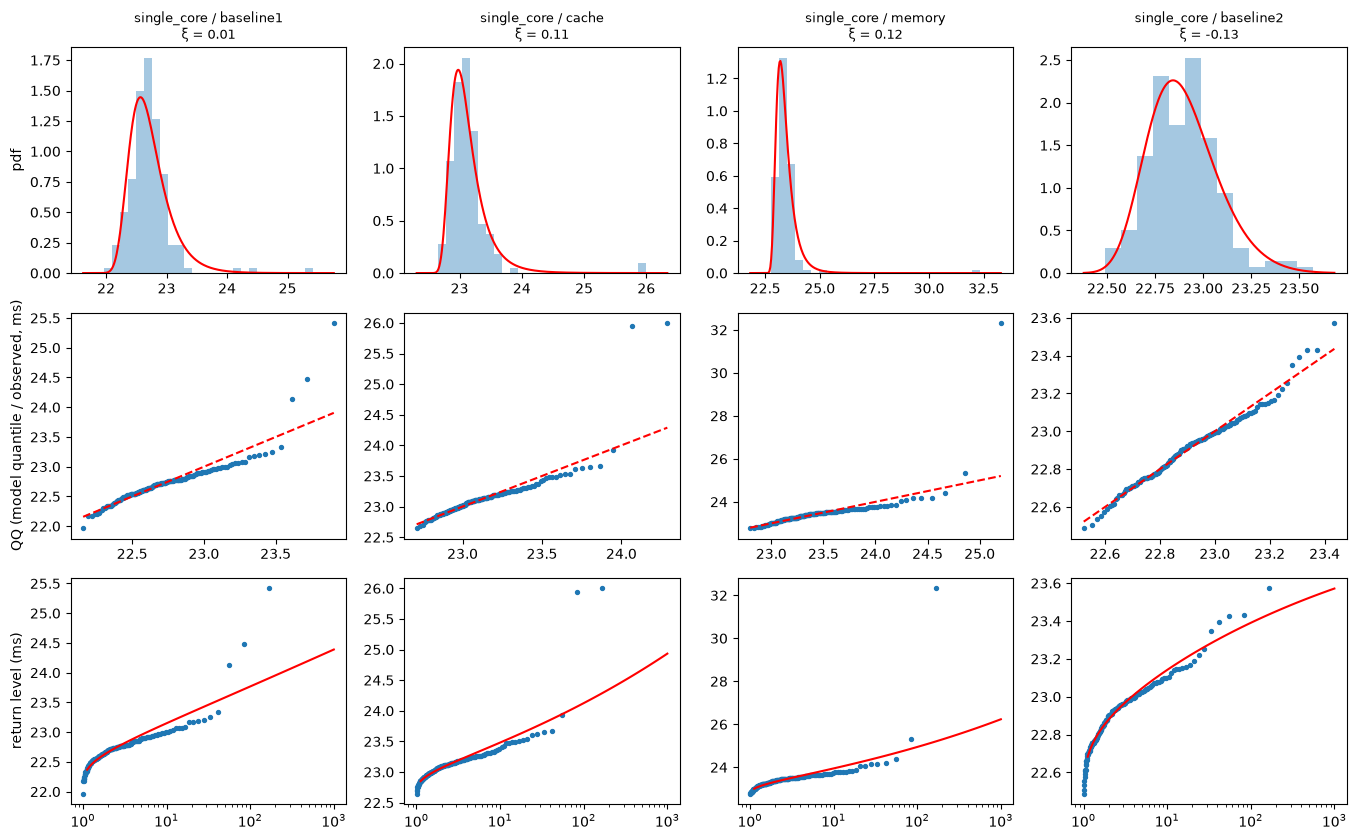

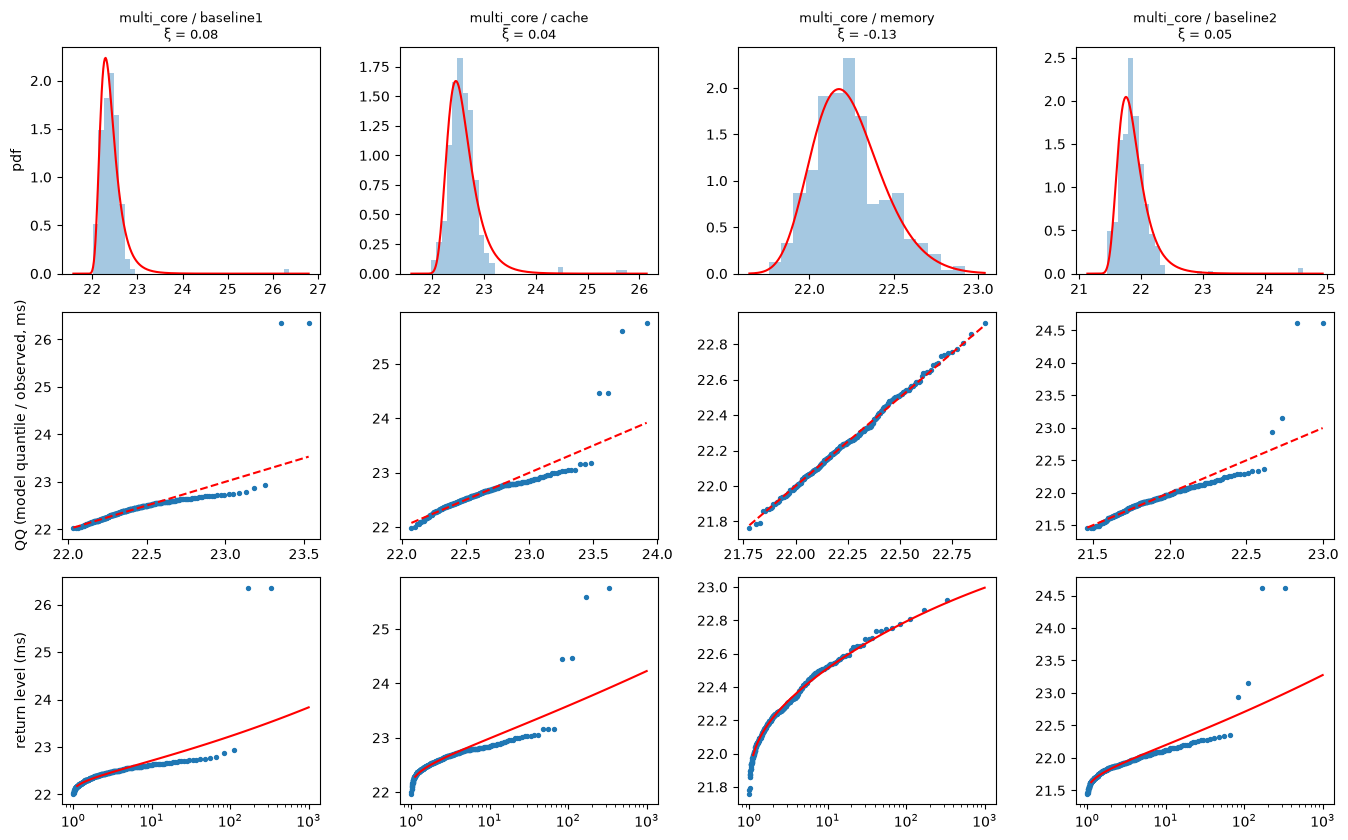

In [5]:
for s in SCENARIOS:
    fig, ax = plt.subplots(3, len(CONDITIONS), figsize=(3.4 * len(CONDITIONS), 8.5), squeeze=False)
    for j, c in enumerate(CONDITIONS):
        x = bm[(s, c)]
        cc, loc, scale = genextreme.fit(x)
        xs = np.sort(x); pr = np.arange(1, len(xs) + 1) / (len(xs) + 1)
        grid = np.linspace(xs.min() - 0.1 * np.ptp(xs), xs.max() + 0.1 * np.ptp(xs), 300)
        ax[0, j].hist(x, bins="auto", density=True, alpha=.4); ax[0, j].plot(grid, genextreme.pdf(grid, cc, loc, scale), "r-")
        ax[0, j].set_title(f"{s} / {c}\nξ = {-cc:.2f}", fontsize=9)
        q = genextreme.ppf(pr, cc, loc, scale)
        ax[1, j].scatter(q, xs, s=8); ax[1, j].plot([q.min(), q.max()], [q.min(), q.max()], "r--")
        T = np.logspace(0.05, 3, 100)
        ax[2, j].semilogx(T, genextreme.isf(1 / T, cc, loc, scale), "r-"); ax[2, j].scatter(1 / (1 - pr), xs, s=8)
    for r, lab in enumerate(["pdf", "QQ (model quantile / observed, ms)", "return level (ms)"]):
        ax[r, 0].set_ylabel(lab)
    plt.tight_layout(); plt.show()

### 2.3 Platform-event check (scenarios with two or more instances)
Both instances run the same clip in lockstep, so a job that is slow on both at the same time points to the platform and not to the task.
For each job the **residual** is its C minus the median C of the same frame (the content effect is removed). A job with a residual above `THR_MS` is a candidate; a candidate that overlaps a candidate of the other instance is a **coincident event**.
`expected by chance` comes from shifting one instance's candidates by random offsets (200 replicates); a small `p-value` means the coincidences are real.

In [6]:
PAIR = [s for s in SCENARIOS if len(SCENARIOS[s]) >= 2]
N_SHIFT = 200
d = data.copy()
d["resid_ms"] = d.C_ms - d.groupby(["scenario", "condition", "instance_id", "frame_idx"]).C_ms.transform("median")
d["platform_event"] = False
rows = []
for s in PAIR:
    ia, ib = SCENARIOS[s][:2]
    for c in CONDITIONS:
        g = d[(d.scenario == s) & (d.condition == c)]
        a = g[(g.instance_id == ia) & (g.resid_ms > THR_MS)]
        b = g[(g.instance_id == ib) & (g.resid_ms > THR_MS)]
        sa, ea, sb, eb = a.start_ns.to_numpy(), a.end_ns.to_numpy(), b.start_ns.to_numpy(), b.end_ns.to_numpy()
        ma, mb = overlap_mask(sa, ea, sb, eb), overlap_mask(sb, eb, sa, ea)
        d.loc[a.index[ma], "platform_event"] = True
        d.loc[b.index[mb], "platform_event"] = True
        t0, span = g.start_ns.min(), g.end_ns.max() - g.start_ns.min()
        null = [overlap_mask(sa, ea, (sb - t0 + o) % span + t0, (sb - t0 + o) % span + t0 + (eb - sb)).sum()
                for o in rng.integers(0, span, N_SHIFT)]
        rows.append(dict(scenario=s, condition=c, **{f"candidates {ia}": len(a), f"candidates {ib}": len(b)},
                         coincident=int(ma.sum()), **{"expected by chance": np.mean(null)},
                         **{"p-value": (1 + np.sum(np.array(null) >= ma.sum())) / (1 + N_SHIFT)},
                         **{"events per 1000 jobs": 1000 * ma.sum() / len(g[g.instance_id == ia])}))
events = pd.DataFrame(rows).set_index(["scenario", "condition"]) if rows else None
display(events.round(3) if events is not None else "no scenario with two instances")

candidates instance0  candidates instance1  coincident  expected by chance  p-value  events per 1000 jobs
scenario   condition                                                                                                           
multi_core baseline1                   177                   174         167               0.230    0.005                 1.671
           cache                        74                    69          67               0.040    0.005                 0.670
           memory                       84                    85          60               0.085    0.005                 0.600
           baseline2                    59                    68          45               0.030    0.005                 0.450

### 2.4 GEV with and without the coincident events
Same fit as 2.1, per instance, once with all jobs and once without the jobs marked as coincident events.
**Reading the table:** if ξ moves from positive to negative and the upper end drops when the events are removed, the heavy tail comes from the platform events and not from the task. The events stay in the budget (conservative); this table only explains the tail.

In [7]:
rows = []
for s in PAIR:
    for c in CONDITIONS:
        for i in SCENARIOS[s]:
            g = d[(d.scenario == s) & (d.condition == c) & (d.instance_id == i)]
            res = {}
            for label, x in (("with", g.C_ms.to_numpy()), ("without", g.C_ms[~g.platform_event].to_numpy())):
                cc, loc, scale = genextreme.fit(block_maxima(x))
                res[label] = (-cc, loc + scale / cc if cc > 0 else np.nan)
            rows.append(dict(scenario=s, condition=c, instance_id=i, removed=int(g.platform_event.sum()),
                             xi_with=res["with"][0], xi_without=res["without"][0],
                             upper_end_with=res["with"][1], upper_end_without=res["without"][1]))
display(pd.DataFrame(rows).set_index(["scenario", "condition", "instance_id"]).round(3) if rows else "no scenario with two instances")

removed  xi_with  xi_without  upper_end_with  upper_end_without
scenario   condition instance_id                                                                 
multi_core baseline1 instance0        167    0.072      -0.241             NaN             23.073
                     instance1        167    0.092      -0.265             NaN             22.871
           cache     instance0         67    0.038      -0.237             NaN             23.380
                     instance1         67    0.048      -0.186             NaN             23.510
           memory    instance0         60   -0.108      -0.115          23.868             23.728
                     instance1         60   -0.142      -0.126          23.413             23.524
           baseline2 instance0         45    0.060      -0.180             NaN             22.777
                     instance1         45    0.052      -0.186             NaN             22.732

### 2.5 Bounds C_p
C_p is the (1−p) quantile of C with an upper 95% confidence bound from a moving-block bootstrap (`L_BOOT` jobs per block, so temporal dependence is kept).
The GEV bound (with the extremal index θ, runs method) is used only at p ≤ `P_GEV`, where it can be compared with the empirical bound. The last column repeats the bound at `P_GEV` with a block twice as long.
**Reading the table:** `C_<p>` columns are the empirical upper bounds; `GEV` should be close to (slightly below) the empirical bound at `P_GEV`; θ < 1 means the extremes cluster a little; a large LRT p-value means a Gumbel tail (ξ = 0) is not rejected.

In [8]:
rows, wide = [], []
for (s, c, i), x in s1_series.items():
    point, ucb = empirical_bound(x, P_LIST)
    th = extremal_index(x, P_GEV)
    gev, xi, p_lrt = gev_theta(x, P_GEV, BLOCK, th)
    ucb2 = empirical_bound(x, [P_GEV], L=2 * L_BOOT)[1][0]
    for k, p in enumerate(P_LIST):
        rows.append(dict(scenario=s, condition=c, instance_id=i, p=p, emp=point[k], ucb=ucb[k], gev=gev if p == P_GEV else np.nan))
    wide.append(dict(scenario=s, condition=c, instance_id=i, **{f"C_{p:g}": ucb[k] for k, p in enumerate(P_LIST)},
                     GEV=gev, theta=th, xi=xi, LRT_p=p_lrt, **{f"C_{P_GEV:g} (2L)": ucb2}))
bounds = pd.DataFrame(rows)
display(pd.DataFrame(wide).set_index(["scenario", "instance_id", "condition"]).sort_index().round(3))

C_0.1  C_0.01  C_0.001    GEV  theta     xi  LRT_p  C_0.001 (2L)
scenario    instance_id condition                                                                  
multi_core  instance0   baseline1 16.998  22.103   22.513 22.462  0.870  0.072  0.002        22.516
                        baseline2 16.365  21.471   21.921 21.892  0.910  0.060  0.048        21.924
                        cache     17.149  22.262   22.713 22.667  0.840  0.038  0.167        22.722
                        memory    16.733  21.891   22.326 22.293  0.880 -0.108  0.070        22.326
            instance1   baseline1 16.926  22.031   22.432 22.367  0.870  0.092  0.000        22.430
                        baseline2 16.323  21.428   21.894 21.868  0.890  0.052  0.083        21.903
                        cache     17.027  22.152   22.605 22.571  0.810  0.048  0.089        22.611
                        memory    16.660  21.814   22.260 22.229  0.880 -0.142  0.015        22.267
single_core instance0   baseline1 17.140  22.323   22.846 22.774  0.750  0.010  0.735        22.850
                        baseline2 17.229  22.509   22.943 22.918  0.900 -0.129  0.008        22.944
                        cache     17.420  22.667   23.149 23.125  0.870  0.105  0.001        23.149
                        memory    17.646  22.930   23.493 23.439  0.790  0.118  0.000        23.507

### 2.6 Profiled bounds per scenario
`C_p_base` is the largest bound over the baselines, `C_p_stress` the largest over the stress conditions (cache, memory), per instance and p.
These two columns are the inputs of every budget below. The ratio `C_p_stress / C_p_base` is the α_cores measured with the task itself.

In [9]:
def envelope(conds):
    return bounds[bounds.condition.isin(conds)].groupby(["scenario", "instance_id", "p"])[["ucb", "gev"]].max()
final = envelope(BASELINES).join(envelope(STRESS), lsuffix="_base", rsuffix="_stress")
final.columns = ["C_p_base", "C_p_base_GEV", "C_p_stress", "C_p_stress_GEV"]
final = final[["C_p_base", "C_p_stress", "C_p_base_GEV", "C_p_stress_GEV"]]
final["stress / base"] = final.C_p_stress / final.C_p_base
display(final.round(3))

C_p_base  C_p_stress  C_p_base_GEV  C_p_stress_GEV  stress / base
scenario    instance_id p                                                                       
multi_core  instance0   0.001    22.513      22.713        22.462          22.667          1.009
                        0.010    22.103      22.262           NaN             NaN          1.007
                        0.100    16.998      17.149           NaN             NaN          1.009
            instance1   0.001    22.432      22.605        22.367          22.571          1.008
                        0.010    22.031      22.152           NaN             NaN          1.006
                        0.100    16.926      17.027           NaN             NaN          1.006
single_core instance0   0.001    22.943      23.493        22.918          23.439          1.024
                        0.010    22.509      22.930           NaN             NaN          1.019
                        0.100    17.229      17.646           NaN             NaN          1.024

### 2.7 Check: bound of the first baseline on the second baseline
The bound C_p of `BASELINES[0]` is applied to `BASELINES[1]` (same VM, a few hours later) with the cluster-aware exceedance test.
**Reading the table:** `exceed` is the number of jobs above the bound, `clusters` the number of independent exceedance groups against `expected clusters`. A failure here, without any configuration change, is the evidence that a drift factor is needed.

In [10]:
b0, b1 = BASELINES[:2]
rows = []
for (s, i, p), r in bounds[bounds.condition == b0].set_index(["scenario", "instance_id", "p"]).iterrows():
    x = s1_series[(s, b1, i)]
    k, kc, exp_cl, pv = exceed_test(x, r.ucb, p)
    rows.append(dict(scenario=s, instance_id=i, p=p, bound=r.ucb, exceed=k, clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
display(pd.DataFrame(rows).set_index(["scenario", "instance_id", "p"]).round(4))

bound  exceed  clusters  expected_clusters  p_value  passed
scenario    instance_id p                                                                 
multi_core  instance0   0.100 16.998    6927       834            833.000    0.491    True
                        0.010 22.103      21        19            589.990    1.000    True
                        0.001 22.513       2         2             90.999    1.000    True
            instance1   0.100 16.926    7020       834            833.000    0.491    True
                        0.010 22.031      34        32            574.990    1.000    True
                        0.001 22.432       2         2             88.999    1.000    True
single_core instance0   0.100 17.140   10910       833            834.000    0.520    True
                        0.010 22.323    1609       762            589.000    0.000   False
                        0.001 22.846     165       134             90.000    0.000   False

## 3. α_drift: variability of the bound between runs and VMs

The workload was run again on other VMs of the same type (and the profiling baselines are two runs hours apart). Every run gets the same bound C_p as above.
α_drift is the **spread of the baseline bounds**: maximum / minimum over all baseline runs of the same scenario, per instance and p; the deployment value per p is the worst instance.
VMs of another type (`EXCLUDE_VMS`) are kept out.

### 3.1 Bounds per run

In [11]:
runs = []
for s, vm in S1_VM.items():
    for c in BASELINES:
        runs.append(dict(run=f"s1_{c}", session="s1", vm=vm, scenario=s, cond=c))
for vm in DRIFT_VMS:
    if vm in EXCLUDE_VMS:
        continue
    for s in SCENARIOS:
        if (S2 / vm / s / "baseline" / "instance0.csv").exists():
            runs.append(dict(run=f"s2_{vm}", session="s2", vm=vm, scenario=s, dir=S2 / vm / s / "baseline"))

run_series, rows = {}, []
s1_ucb = bounds.set_index(["scenario", "condition", "instance_id", "p"])
for r in runs:
    for i in SCENARIOS[r["scenario"]]:
        if r["session"] == "s1":                                  # same numbers as section 2.5
            x = s1_series[(r["scenario"], r["cond"], i)]
            point, ucb = [s1_ucb.loc[(r["scenario"], r["cond"], i, p)].emp for p in P_LIST], [s1_ucb.loc[(r["scenario"], r["cond"], i, p)].ucb for p in P_LIST]
        else:
            x = load_series(r["dir"] / f"{i}.csv")
            point, ucb = empirical_bound(x, P_LIST)
        run_series[(r["run"], r["scenario"], i)] = x
        for k, p in enumerate(P_LIST):
            rows.append(dict(run=r["run"], session=r["session"], vm=r["vm"], scenario=r["scenario"], instance_id=i, p=p, n=len(x), emp=point[k], ucb=ucb[k]))
bnd = pd.DataFrame(rows)
display(bnd.pivot_table(index=["scenario", "instance_id", "run", "vm"], columns="p", values="ucb").round(3))

p                                             0.001  0.010  0.100
scenario    instance_id run          vm                          
multi_core  instance0   s1_baseline1 worker7 22.513 22.103 16.998
                        s1_baseline2 worker7 21.921 21.471 16.365
                        s2_worker6   worker6 22.288 21.618 16.492
            instance1   s1_baseline1 worker7 22.432 22.031 16.926
                        s1_baseline2 worker7 21.894 21.428 16.323
                        s2_worker6   worker6 22.282 21.645 16.530
single_core instance0   s1_baseline1 worker6 22.846 22.323 17.140
                        s1_baseline2 worker6 22.943 22.509 17.229
                        s2_worker6   worker6 22.439 21.815 16.626

### 3.2 α_drift
**Reading the table:** one row per scenario and p, `alpha_drift` is the factor used in the budgets, `n_runs` the number of runs behind it (with few runs the spread is a coarse estimate).

In [12]:
spread = bnd.groupby(["scenario", "instance_id", "p"]).ucb.agg(lambda v: v.max() / v.min())
alpha_drift_p = spread.groupby(["scenario", "p"]).max()               # worst instance, per p
t = alpha_drift_p.unstack("p")
t["n_runs"] = bnd.groupby("scenario").run.nunique()
display(t.round(4))

p,0.001,0.010,0.100,n_runs
scenario,,,,
multi_core,1.027,1.029,1.039,3
single_core,1.022,1.032,1.036,3


### 3.3 Leave-one-out check of the spread rule
For each baseline run except the reference (`BASELINES[0]` of the profiling session): α is the spread of all **other** runs, the reference bound × α is applied to the held-out run with the cluster-aware exceedance test.
**Reading the table:** `passed` is False when the held-out run exceeds the inflated bound more often than allowed (worst instance shown). A failure typically means the held-out run was the one that carried the largest drift.

In [13]:
ref = bnd[bnd.run == f"s1_{BASELINES[0]}"].set_index(["scenario", "instance_id", "p"]).ucb
rows = []
for (s, run), _ in bnd[bnd.run != f"s1_{BASELINES[0]}"].groupby(["scenario", "run"]):
    others = bnd[(bnd.scenario == s) & (bnd.run != run)]
    a_loo = others.groupby(["instance_id", "p"]).ucb.agg(lambda v: v.max() / v.min())
    for i in SCENARIOS[s]:
        for p in TEST_P:
            C = ref[(s, i, p)] * a_loo[(i, p)]
            k, kc, exp_cl, pv = exceed_test(run_series[(run, s, i)], C, p)
            rows.append(dict(scenario=s, run=run, instance_id=i, p=p, alpha_loo=a_loo[(i, p)], clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
loo = pd.DataFrame(rows)
worst = loo.sort_values("p_value").groupby(["scenario", "run", "p"]).head(1).sort_values(["scenario", "run", "p"]).set_index(["scenario", "run", "p"])
display(worst.round(4))
print(f"passed {int(loo.passed.sum())} of {len(loo)} (all instances)")

instance_id  alpha_loo  clusters  expected_clusters  p_value  passed
scenario    run          p                                                                         
multi_core  s1_baseline2 0.001   instance0      1.010         2             90.999    1.000    True
                         0.010   instance0      1.022         2            589.990    1.000    True
            s2_worker6   0.001   instance1      1.025         8             51.000    1.000    True
                         0.010   instance0      1.029        11            486.000    1.000    True
single_core s1_baseline2 0.001   instance0      1.018         5             90.000    1.000    True
                         0.010   instance0      1.023       135            589.000    1.000    True
            s2_worker6   0.001   instance0      1.004         7             63.000    1.000    True
                         0.010   instance0      1.008        35            532.000    1.000    True

passed 12 of 12 (all instances)


## 4. α_cores on a second VM and the rule for m

Section 2.6 gives the stress effect on the profiling VM. Here the same workload is run under the stressor `STRESS_COND` on a **second VM of the same type** (`TEST_VM`), with its baseline from section 3.
This gives (a) the stressed bound **measured** on a VM that did not profile the scenario, used to check the budgets in section 5, and (b) the task's own stress ratio there, to decide how many enemy cores `m` the platform factor should use.

### 4.1 Stressed bound on the test VM

In [14]:
stress_run = {s: f"s2_{TEST_VM[s]}_{STRESS_COND}" for s in SCENARIOS}
base_run = {s: f"s2_{TEST_VM[s]}" for s in SCENARIOS}
have = [s for s in SCENARIOS if (S2 / TEST_VM[s] / s / STRESS_COND / "instance0.csv").exists()]
for s in set(SCENARIOS) - set(have):
    print(f"skipped {s}: no {STRESS_COND} run on {TEST_VM[s]} yet")

rows = []
for s in have:
    for i in SCENARIOS[s]:
        x = load_series(S2 / TEST_VM[s] / s / STRESS_COND / f"{i}.csv")
        run_series[(stress_run[s], s, i)] = x
        point, ucb = empirical_bound(x, P_LIST)
        for k, p in enumerate(P_LIST):
            rows.append(dict(scenario=s, instance_id=i, p=p, n=len(x), meas_point=point[k], meas_ucb=ucb[k]))
meas = pd.DataFrame(rows).set_index(["scenario", "instance_id", "p"])
display(meas.reset_index().pivot_table(index=["scenario", "instance_id", "n"], columns="p", values="meas_ucb").round(3))

p                              0.001  0.010  0.100
scenario    instance_id n                         
multi_core  instance0   49903 22.442 22.017 16.987
            instance1   49903 22.467 22.049 17.026
single_core instance0   50000 22.344 21.686 16.500

### 4.2 α_cores on the test VM against the profiling VM
`alpha_cores_s1` = stressed / baseline bound on the profiling VM (section 2.6, worst instance); `alpha_cores_test` = the same ratio on the test VM, with a bootstrap 95% interval.
`stress_over_drift` ≈ 1 means that stress and VM drift multiply (the stress effect is the same on both VMs).

In [15]:
have_base = [s for s in have if ((bnd.scenario == s) & (bnd.run == base_run[s])).any()]
for s in set(have) - set(have_base):
    print(f"skipped {s}: no baseline run on {TEST_VM[s]} (alpha_drift/results/{TEST_VM[s]}/{s}/baseline)")
base_test = bnd[bnd.run.isin(base_run.values())].set_index(["scenario", "instance_id", "p"]).ucb
rows = []
for s in have_base:
    for i in SCENARIOS[s]:
        rat = boot_dist(run_series[(stress_run[s], s, i)]) / boot_dist(run_series[(base_run[s], s, i)])
        for k, p in enumerate(P_LIST):
            b_t, s_t = base_test[(s, i, p)], meas.loc[(s, i, p), "meas_ucb"]
            s1_mem = bounds[(bounds.scenario == s) & (bounds.condition == STRESS_COND) & (bounds.instance_id == i) & (bounds.p == p)].ucb.iloc[0]
            lo, hi = np.percentile(rat[:, k], [2.5, 97.5])
            rows.append(dict(scenario=s, instance_id=i, p=p, alpha_cores_s1=final.loc[(s, i, p), "stress / base"], alpha_cores_test=s_t / b_t,
                             ci_lo=lo, ci_hi=hi, stress_over_drift=(s_t / s1_mem) / (b_t / final.loc[(s, i, p), "C_p_base"])))
val = pd.DataFrame(rows)
t = val.groupby(["scenario", "p"]).agg(alpha_cores_s1=("alpha_cores_s1", "max"), alpha_cores_test=("alpha_cores_test", "max"),
                                       lo=("ci_lo", "min"), hi=("ci_hi", "max"), stress_over_drift=("stress_over_drift", "max"))
t["95% interval"] = t.lo.map("{:.3f}".format) + " - " + t.hi.map("{:.3f}".format)
display(t[["alpha_cores_s1", "alpha_cores_test", "95% interval", "stress_over_drift"]].round(3))

skipped single_core: no baseline run on worker7 (alpha_drift/results/worker7/single_core/baseline)


alpha_cores_s1  alpha_cores_test   95% interval  stress_over_drift
scenario   p                                                                        
multi_core 0.001           1.009             1.008  1.004 - 1.016              1.016
           0.010           1.007             1.019  1.016 - 1.021              1.029
           0.100           1.009             1.030  1.029 - 1.033              1.046

### 4.3 Decision: m
Route 2b multiplies the baseline bound by a platform factor α_cores,platform(m) (`ALPHA_PLATFORM`, measured with synthetic victims, m = number of enemy cores). It is safe when **the task is less sensitive to the enemy than the victims**.
**Rule, fixed before looking:** if the upper end of the task's stress ratio on the test VM is below the factor of the m actually used, keep m; otherwise use the next larger m. Set the decision in `M_USED` in the configuration cell and re-run from there.

In [16]:
sens = val.groupby("scenario").agg(task_alpha_cores_test=("alpha_cores_test", "max"), task_upper_ci=("ci_hi", "max"))
sens["m used"] = [M_USED[s] for s in sens.index]
sens["platform factor"] = [ALPHA_PLATFORM[M_USED[s]] for s in sens.index]
sens["task less sensitive"] = sens.task_upper_ci < sens["platform factor"]
display(sens.round(3))

,task_alpha_cores_test,task_upper_ci,m used,platform factor,task less sensitive
scenario,,,,,
multi_core,1.030,1.033,2,1.060,True


## 5. Budgets

T is the period and deadline; a job misses when C > Q (this relies on the HCBS assumption, section 9).

| | Route 1 (full profiling) | Route 2b (platform factors) | Route 3 (HWM, industrial practice) |
|---|---|---|---|
| Formula | Q = C_p^stress × α_drift | Q = C_p^base × α_cores,platform(m) × α_drift | Q = max C over stressed runs × α_drift / 0.96 |
| Needs | baseline + stress profiling | baseline profiling only | stress profiling |
| Depends on p | yes | yes | **no**: one budget for every p |

α_drift is taken per p (HWM: at `HWM_P`). A multi-core deployment has one reservation for all instances, so the deployment budget Q* is the maximum over the instances. Q*/T is the reserved utilisation; admission needs Q*/T ≤ `ADMISSION_MAX`.

### 5.1 Budgets Q* and admission
**Reading the table:** each cell is `Q* in ms (Q*/T)`. Only the variants in use are shown (Route 2b with `M_USED`); the conservative m = largest in `ALPHA_PLATFORM` is kept in `bt_all` for comparisons.

In [17]:
def hwm_ms(scen, inst):
    """max C (ms) over the stressed profiling runs; platform events stay in (conservative), stalls (C > 2 T) are left out"""
    return max(float(s1_series[(scen, c, inst)][s1_series[(scen, c, inst)] <= 2 * T_MS].max()) for c in HWM_STRESS)

def budget_table(m_used):
    rows = []
    for (s, i, p), r in final.iterrows():
        a = alpha_drift_p[(s, p)]
        rows.append(dict(scenario=s, instance_id=i, p=p, route="Route 1", Q_ms=r.C_p_stress * a))
        rows.append(dict(scenario=s, instance_id=i, p=p, route=f"Route 2b (m={m_used[s]})", Q_ms=r.C_p_base * ALPHA_PLATFORM[m_used[s]] * a))
        rows.append(dict(scenario=s, instance_id=i, p=p, route="HWM", Q_ms=hwm_ms(s, i) * alpha_drift_p[(s, HWM_P)] / HWM_MARGIN))
    return pd.DataFrame(rows)

M_ALT = {s: max(ALPHA_PLATFORM) for s in SCENARIOS}                    # conservative alternative, for comparison
bt_all = pd.concat([budget_table(M_USED), budget_table(M_ALT)]).drop_duplicates(["scenario", "instance_id", "p", "route"]).reset_index(drop=True)
dep = bt_all.groupby(["scenario", "route", "p"], as_index=False).Q_ms.max()          # one reservation: max over instances
dep["Q_over_T"] = dep.Q_ms / T_MS
dep["admitted"] = dep.Q_over_T <= ADMISSION_MAX
dep["in_use"] = [r in ("Route 1", "HWM") or r == f"Route 2b (m={M_USED[s]})" for s, r in zip(dep.scenario, dep.route)]

u = dep[dep.in_use].assign(cell=lambda x: x.Q_ms.round(2).astype(str) + " (" + x.Q_over_T.round(2).astype(str) + ")")
t = u.pivot_table(index=["scenario", "route"], columns="p", values="cell", aggfunc="first")
t["all admitted"] = u.groupby(["scenario", "route"]).admitted.all()
display(t)

p                                  0.001         0.010         0.100   all admitted
scenario    route                                                                  
multi_core  HWM             27.56 (0.66)  27.56 (0.66)  27.56 (0.66)           True
            Route 1         23.33 (0.56)  22.92 (0.55)  17.81 (0.43)           True
            Route 2b (m=2)  24.51 (0.59)  24.12 (0.58)  18.72 (0.45)           True
single_core HWM             34.43 (0.83)  34.43 (0.83)  34.43 (0.83)           True
            Route 1         24.02 (0.58)  23.66 (0.57)  18.29 (0.44)           True
            Route 2b (m=3)  26.04 (0.62)  25.78 (0.62)  19.82 (0.48)           True

### 5.2 Risk curves: budget for any p, risk of any budget
risk(Q | T) = P(C > Q). The curve is drawn in p from the profiled traces (point estimates; α_drift interpolated in log p), so it passes through the same factors as the budgets. Markers are the budgets Q* of 5.1 (they use the upper confidence bound, so the horizontal gap to the curve is the margin of the bootstrap).
The functions defined here can be used directly: `budget_at(scenario, "Route 1", 0.005)` gives the budget for a tolerance, `risk_at(scenario, "Route 1", 23.0)` the risk of a budget in ms.

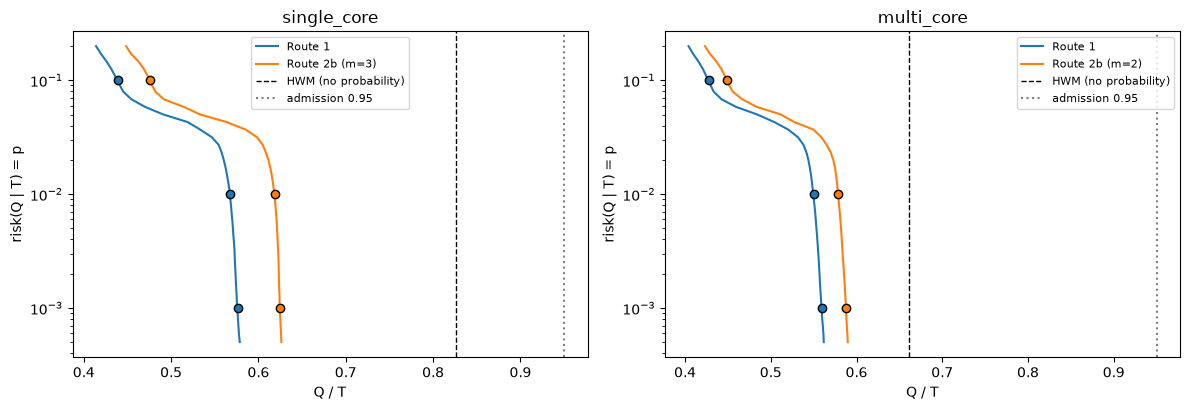

In [18]:
def q_point(scen, conds, p):
    return max(np.quantile(s1_series[(scen, c, i)], 1 - p) for c in conds for i in SCENARIOS[scen])

def alpha_drift_at(scen, p):
    a = alpha_drift_p[scen].sort_index()
    return float(np.exp(np.interp(np.log(p), np.log(a.index.values), np.log(a.values))))

def _route_name(scen, route):
    return "Route 1" if route == "Route 1" else f"Route 2b (m={M_USED[scen]})"

_curves = {}
def _curve(scen, route):
    key = (scen, _route_name(scen, route))
    if key not in _curves:
        conds, plat = (STRESS, 1.0) if key[1] == "Route 1" else (BASELINES, ALPHA_PLATFORM[M_USED[scen]])
        pg = np.logspace(-4, np.log10(0.3), 60)
        _curves[key] = (pg, np.array([q_point(scen, conds, p) * plat * alpha_drift_at(scen, p) for p in pg]))
    return _curves[key]

def budget_at(scen, route, p):
    """budget Q (ms) for the tolerance p"""
    pg, q = _curve(scen, route)
    return float(np.exp(np.interp(np.log(p), np.log(pg), np.log(q))))

def risk_at(scen, route, Q_ms):
    """per-job miss probability of the budget Q (ms); end values (1e-4, 0.3) outside the curve"""
    pg, q = _curve(scen, route)
    o = np.argsort(q)
    return float(np.exp(np.interp(np.log(Q_ms), np.log(q[o]), np.log(pg[o]))))

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, s in zip(axes[0], SCENARIOS):
    pg = np.logspace(-3.3, -0.7, 40)
    for route in ("Route 1", "Route 2b"):
        name = _route_name(s, route)
        conds, plat = (STRESS, 1.0) if route == "Route 1" else (BASELINES, ALPHA_PLATFORM[M_USED[s]])
        q = np.array([q_point(s, conds, p) * plat * alpha_drift_at(s, p) for p in pg])
        line, = ax.semilogy(q / T_MS, pg, label=name)
        m = dep[(dep.scenario == s) & (dep.route == name)]
        ax.plot(m.Q_over_T, m.p, "o", color=line.get_color(), mec="k", ms=6)
    h = dep[(dep.scenario == s) & (dep.route == "HWM")]
    ax.axvline(h.Q_over_T.iloc[0], color="k", ls="--", lw=1, label="HWM (no probability)")
    ax.axvline(ADMISSION_MAX, color="grey", ls=":", label=f"admission {ADMISSION_MAX}")
    ax.set(title=s, xlabel="Q / T", ylabel="risk(Q | T) = p"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Budgets for other tolerances (point estimates, `Q in ms (Q/T)`):

In [19]:
P_TABLE = (0.1, 0.03, 0.01, 0.003, 0.001, 0.0003, 0.0001)
display(pd.DataFrame({(s, _route_name(s, r)): {f"p={p:g}": f"{budget_at(s, r, p):.1f} ({budget_at(s, r, p) / T_MS:.2f})" for p in P_TABLE}
                      for s in SCENARIOS for r in ("Route 1", "Route 2b")}).T)

p=0.1       p=0.03       p=0.01      p=0.003      p=0.001     p=0.0003     p=0.0001
single_core Route 1         18.3 (0.44)  22.9 (0.55)  23.6 (0.57)  23.9 (0.57)  24.0 (0.58)  24.2 (0.58)  24.6 (0.59)
            Route 2b (m=3)  19.8 (0.48)  25.0 (0.60)  25.8 (0.62)  25.9 (0.62)  26.0 (0.62)  26.2 (0.63)  26.3 (0.63)
multi_core  Route 1         17.8 (0.43)  22.3 (0.53)  22.9 (0.55)  23.1 (0.56)  23.3 (0.56)  23.5 (0.56)  23.7 (0.57)
            Route 2b (m=2)  18.7 (0.45)  23.4 (0.56)  24.1 (0.58)  24.3 (0.58)  24.5 (0.59)  24.6 (0.59)  24.7 (0.59)

### 5.3 Check on the test VM: budgets against the measured stressed bound
The budgets (profiling-session inputs only) are compared with the stressed bound **measured on the test VM** (4.1), at the p in `TEST_P`.
**Pass rule, fixed before looking:** (1) Q ≥ the measured stressed bound, and (2) the cluster-aware exceedance test of Q on the stressed test-VM run passes. `b/m` = budget / measured bound (min over instances; ≥ 1 covers it). The conservative m is shown as the second Route 2b row.

In [20]:
mrg = bt_all.merge(meas.reset_index()[["scenario", "instance_id", "p", "meas_ucb"]], on=["scenario", "instance_id", "p"])
mrg["b/m"] = mrg.Q_ms / mrg.meas_ucb
mrg["Q >= measured"] = mrg.Q_ms >= mrg.meas_ucb
rows = []
for r in mrg[mrg.p.isin(TEST_P)].itertuples():
    k, kc, exp_cl, pv = exceed_test(run_series[(stress_run[r.scenario], r.scenario, r.instance_id)], r.Q_ms, r.p)
    rows.append(dict(scenario=r.scenario, route=r.route, p=r.p, passed=pv > 0.05))
exc = pd.DataFrame(rows)
t = mrg[mrg.p.isin(TEST_P)]
verdict = t.groupby(["scenario", "route"])["Q >= measured"].all().to_frame().join(exc.groupby(["scenario", "route"]).passed.all().rename("exceedance test"))
verdict["pass"] = verdict.all(axis=1)
for p in TEST_P:
    verdict[f"b/m p={p:g}"] = t[t.p == p].groupby(["scenario", "route"])["b/m"].min()
display(verdict.round(3))

Q >= measured  exceedance test  pass  b/m p=0.01  b/m p=0.001
scenario    route                                                                        
multi_core  HWM                      True             True  True       1.244        1.220
            Route 1                  True             True  True       1.034        1.033
            Route 2b (m=2)           True             True  True       1.090        1.087
            Route 2b (m=3)           True             True  True       1.142        1.138
single_core HWM                      True             True  True       1.588        1.541
            Route 1                  True             True  True       1.091        1.075
            Route 2b (m=3)           True             True  True       1.189        1.165

## 6. p_floor: stalls and late jobs that no budget removes

With a generous budget a job can still be skipped or late (VM stalls, late starts). p_floor is that rate; tolerances below it are not meaningful.
A job is *bad* if it was skipped or late (R > T). An *event* is a maximal run of consecutive bad jobs (one stall that skips 56 jobs counts once); events are merged across the instances of a run. The **bad-job rate** is the per-job floor to compare with p; the **event rate** has a one-sided 95% Clopper–Pearson bound.
**Reading the table:** `bad-job rate` below the smallest p of interest means the platform does not limit the tolerance; `longest event` is the longest stall in jobs.

In [21]:
pf_runs = [("S1", s, c, S1 / s / c) for s in SCENARIOS for c in CONDITIONS]
pf_runs += [("S2", s, f"baseline@{vm}", S2 / vm / s / "baseline") for vm in DRIFT_VMS for s in SCENARIOS
            if vm not in EXCLUDE_VMS and (S2 / vm / s / "baseline" / "instance0.csv").exists()]
pf, bad_by = [], {}
for sess, s, c, dr in pf_runs:
    for i in SCENARIOS[s]:
        t_ns = json.load(open(dr / f"{i}.meta.json"))["args"]["period_ms"] * 1e6
        df = pd.read_csv(dr / f"{i}.csv", usecols=["job_id", "response_ns", "skipped", "warmup"]).sort_values("job_id")
        df = df[df.warmup == 0]
        bad = (df.skipped == 1).to_numpy() | ((df.skipped == 0) & (df.response_ns > t_ns)).to_numpy()
        first = bad & ~np.concatenate(([False], bad[:-1]))
        longest = int(np.bincount(np.cumsum(first)[bad]).max()) if bad.any() else 0
        bad_by.setdefault((sess, s, c), []).append(bad)
        pf.append(dict(session=sess, jobs=len(df), bad_jobs=int(bad.sum()), events=int(first.sum()), longest=longest))
pf = pd.DataFrame(pf)

def merged_events(session):
    tot = 0
    for (sess, s, c), arrs in bad_by.items():
        if sess == session:
            u = np.logical_or.reduce(arrs)
            tot += int((u & ~np.concatenate(([False], u[:-1]))).sum())
    return tot

rows = []
for label, sess in (("all runs", None), ("S1 (profiling)", "S1"), ("S2 (other VMs)", "S2")):
    g = pf if sess is None else pf[pf.session == sess]
    n, k = int(g.jobs.sum()), (merged_events("S1") + merged_events("S2") if sess is None else merged_events(sess))
    rows.append({"runs": label, "jobs": n, "events": k, "event rate": f"{k / n:.1e}", "95% upper": f"{cp_upper(k, n):.1e}",
                 "bad-job rate": f"{g.bad_jobs.sum() / n:.1e}", "longest event (jobs)": int(g.longest.max())})
pfloor = pd.DataFrame(rows).set_index("runs")
pfloor_events, pfloor_jobs = merged_events("S1") + merged_events("S2"), int(pf.jobs.sum())
display(pfloor)

,jobs,events,event rate,95% upper,bad-job rate,longest event (jobs)
runs,,,,,,
all runs,1500000,5,3.3e-06,7.0e-06,1.4e-04,72
S1 (profiling),1200000,5,4.2e-06,8.8e-06,1.7e-04,72
S2 (other VMs),300000,0,0.0e+00,1.0e-05,0.0e+00,0


## 7. Offline replay of the budgets

### 7.1 Held-out baselines
Each budget Q* is replayed on the held-out runs (the session-2 baselines of other VMs) with the miss model C > Q. Per scenario, route and p, the worst case over runs and instances:
`miss_over_p` ≤ 1 means the budget meets p; `max_consec` is the longest run of consecutive misses; `mk_worst_k<k>` the minimum number of met deadlines in any window of k jobs; `over_budget_pct` = mean of Q*/Q_oracle − 1, with Q_oracle the (1−p) quantile of the held-out trace (the smallest budget that meets p there).

In [22]:
held = bnd[bnd.session == "s2"][["run", "scenario"]].drop_duplicates()
off = []
for run, s in held.itertuples(index=False):
    for i in SCENARIOS[s]:
        x = run_series[(run, s, i)]
        for r in dep[dep.scenario == s].itertuples():
            off.append(dict(heldout=run, scenario=s, route=r.route, p=r.p, in_use=r.in_use, over_budget=r.Q_ms / np.quantile(x, 1 - r.p) - 1, **replay(x, r.Q_ms, r.p)))
off = pd.DataFrame(off)
o = off[off.in_use & off.p.isin(TEST_P)]
display(o.groupby(["scenario", "route", "p"]).agg(miss_over_p=("miss_over_p", "max"), max_consec=("max_consec", "max"),
                                                   over_budget_pct=("over_budget", lambda v: v.mean() * 100),
                                                   **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST}).round(3))

miss_over_p  max_consec  over_budget_pct  mk_worst_k10  mk_worst_k100
scenario    route          p                                                                           
multi_core  HWM            0.001        0.040           2           24.198             8             98
                           0.010        0.004           2           27.559             8             98
            Route 1        0.001        0.200           7            5.120             3             93
                           0.010        0.024           7            6.070             3             93
            Route 2b (m=2) 0.001        0.140           7           10.450             3             93
                           0.010        0.015           7           11.631             3             93
single_core HWM            0.001        0.000           0           54.004            10            100
                           0.010        0.000           0           58.064            10            100
            Route 1        0.001        0.080           2            7.433             7             97
                           0.010        0.010           2            8.603             7             97
            Route 2b (m=3) 0.001        0.050           1           16.458             9             99
                           0.010        0.005           1           18.337             9             99

Trade-off figure: over-budget (cost) against `miss rate / p` (calibration). Left of the dotted line is within the tolerance; the best variant is far left and low.

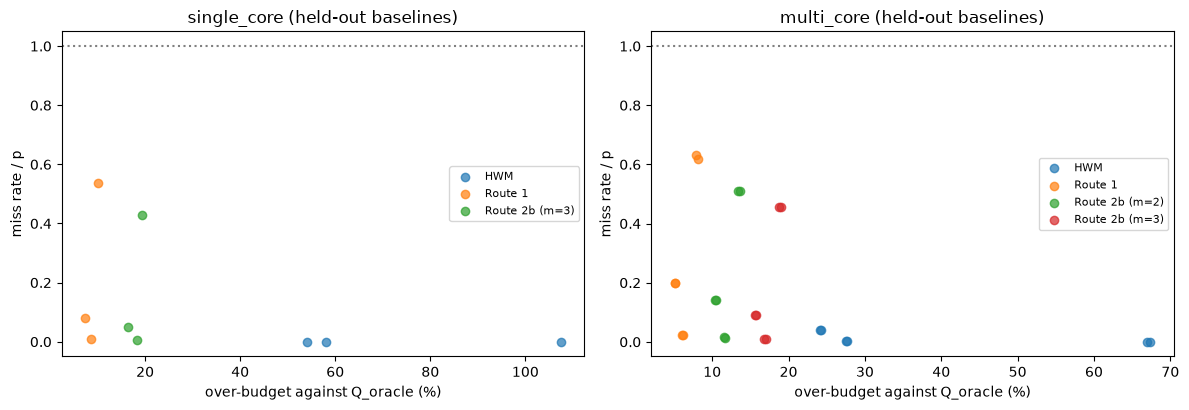

In [23]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, s in zip(axes[0], SCENARIOS):
    for route, g in off[off.scenario == s].groupby("route"):
        ax.scatter(g.over_budget * 100, g.miss_over_p, label=route, alpha=.7)
    ax.axhline(1, color="grey", ls=":")
    ax.set(title=f"{s} (held-out baselines)", xlabel="over-budget against Q_oracle (%)", ylabel="miss rate / p"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7.2 Burst check on the stressed profiling traces
The held-out runs are baselines only; bursts of misses would show on the stressed traces. They are profiling data, so this checks the **structure** of the misses (consecutive misses, worst-case (m,k)) at the budgets Q*, not the calibration. Worst case over the stress conditions and instances.

In [24]:
burst = []
for s in SCENARIOS:
    for c in STRESS:
        for i in SCENARIOS[s]:
            for r in dep[(dep.scenario == s) & dep.in_use].itertuples():
                burst.append(dict(scenario=s, condition=c, route=r.route, p=r.p, **replay(s1_series[(s, c, i)], r.Q_ms, r.p)))
burst = pd.DataFrame(burst)
display(burst[burst.p.isin(TEST_P)].groupby(["scenario", "route", "p"]).agg(
    miss_over_p=("miss_over_p", "max"), max_consec=("max_consec", "max"), **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST}).round(3))

miss_over_p  max_consec  mk_worst_k10  mk_worst_k100
scenario    route          p                                                          
multi_core  HWM            0.001        0.000           0            10            100
                           0.010        0.000           0            10            100
            Route 1        0.001        0.040           2             8             98
                           0.010        0.017           3             7             97
            Route 2b (m=2) 0.001        0.020           2             8             98
                           0.010        0.003           2             8             98
single_core HWM            0.001        0.000           0            10            100
                           0.010        0.000           0            10            100
            Route 1        0.001        0.110           4             6             96
                           0.010        0.034           4             6             96
            Route 2b (m=3) 0.001        0.030           3             7             97
                           0.010        0.003           3             7             97

## 8. Online validation under KubeDeadline

### 8.1 Run matrix
The budgets are given to KubeDeadline as the reservation (`runtime` in µs, rounded **up** so the reservation is never below Q*, for `period` = T) and the task is run with and without the memory enemy, on a VM that did not profile the scenario. The matrix below is what has to be run (the HWM route has one budget for every p). The manifests and `run_validation.sh` of the `validation/` folder are built from it.

In [25]:
mat = []
for r in pd.concat([dep[dep.in_use & (dep.route != "HWM")], dep[(dep.route == "HWM") & (dep.p == dep.p.max())].assign(p="all")]).itertuples():
    mat.append(dict(scenario=r.scenario, route=r.route, p=r.p, runtime_us=math.ceil(r.Q_ms * 1000), period_us=round(T_MS * 1000), Q_over_T=round(r.Q_over_T, 3), admitted=r.admitted))
mat = pd.DataFrame(mat)
display(mat.set_index(["scenario", "route", "p"]))
n_runs = 2 * len(mat)
print(f"{n_runs} runs (each line runs without and with the enemy) x {JOBS_VALIDATION} jobs = about {n_runs * JOBS_VALIDATION * T_MS / 3.6e6:.1f} h in total")

runtime_us  period_us  Q_over_T  admitted
scenario    route          p                                               
multi_core  Route 1        0.001       23327      41667     0.560      True
                           0.010       22917      41667     0.550      True
                           0.100       17813      41667     0.427      True
            Route 2b (m=2) 0.001       24509      41667     0.588      True
                           0.010       24119      41667     0.579      True
                           0.100       18716      41667     0.449      True
single_core Route 1        0.001       24022      41667     0.577      True
                           0.010       23660      41667     0.568      True
                           0.100       18287      41667     0.439      True
            Route 2b (m=3) 0.001       26040      41667     0.625      True
                           0.010       25780      41667     0.619      True
                           0.100       19819      41667     0.476      True
multi_core  HWM             all        27560      41667     0.661      True
single_core HWM             all        34435      41667     0.826      True

28 runs (each line runs without and with the enemy) x 50000 jobs = about 16.2 h in total


### 8.2 Pass rule and verdicts
Results are read from `validation/results/<scenario>/<route>/<p tag>_<interference>/` (only runs marked `.done`).

**Pass rule, fixed before looking.** A *miss* is a late job (`deadline_met = 0`) or a skipped job; a *miss event* is a run of consecutive misses. An event that contains a job with C > Q* is a **budget miss**; an event without such a job is a **platform stall** (the budget cannot prevent it): reported apart, not counted. A run **passes** at p when its budget-miss rate (worst instance) is ≤ p. With the one-sided 95% Clopper–Pearson bound: `PASS` if the bound ≤ p, `pass?` if the point estimate ≤ p < bound (inconclusive), `FAIL` if the point estimate > p.
**Reading the table:** `miss/p` = budget-miss rate / p (below 1 is within the tolerance); one column pair per interference condition.

In [26]:
def analyse_instance(df, runtime_us, p):
    n = len(df)
    cpu = df.cpu_ns.to_numpy(dtype=float) / 1e3                          # us
    skipped = (df.skipped == 1).to_numpy()
    late = ((df.skipped == 0) & (df.deadline_met == 0)).to_numpy()
    miss = skipped | late
    first = miss & ~np.concatenate(([False], miss[:-1]))
    ev = np.cumsum(first); n_ev = int(first.sum())
    lens = np.bincount(ev[miss], minlength=n_ev + 1)
    def budget_events(thr):                                              # events with a job above thr x Q*
        be = np.zeros(n_ev + 1, dtype=bool)
        hit = (~skipped) & (cpu / runtime_us > thr) & miss
        if hit.any():
            be[ev[hit]] = True
        be[0] = False
        return be
    be, bm_ = budget_events(1.0), budget_events(ACCOUNTING_MARGIN)
    r = cpu / runtime_us; ex = ~skipped
    lo, mid, hi = ex & (r <= ACCOUNTING_MARGIN), ex & (r > ACCOUNTING_MARGIN) & (r <= 1.0), ex & (r > 1.0)
    c_oracle = float(np.quantile(cpu[~np.isnan(cpu)], 1 - p))
    return dict(n=n, budget_misses=int((miss & be[ev]).sum()), budget_misses_m=int((miss & bm_[ev]).sum()),
                budget_longest=int(lens[be].max()) if be.any() else 0,
                stall_events=n_ev - int(bm_.sum()), stall_jobs=int(miss.sum() - (miss & bm_[ev]).sum()),
                n_lo=int(lo.sum()), late_lo=int((lo & late).sum()), n_mid=int(mid.sum()), late_mid=int((mid & late).sum()),
                n_hi=int(hi.sum()), late_hi=int((hi & late).sum()), c_oracle_ms=c_oracle / 1e3, over_budget=runtime_us / c_oracle - 1)

def run_dirs():
    """(scenario, route, p, cond, folder) of every collected run; a HWM run is judged at every tolerance"""
    for s in SCENARIOS:
        for route in VAL_ROUTES:
            for tag, p in VAL_P.items():
                for cond in ("none", "memory"):
                    yield s, route, p, cond, VAL / s / route / f"{tag}_{cond}"
        for cond in ("none", "memory"):
            for p in VAL_P.values():
                yield s, "hwm", p, cond, VAL / s / "hwm" / f"all_{cond}"

rows = []
for s, route, p, cond, dr in run_dirs():
    if not (dr / ".done").exists():
        continue
    runtime_us = int(re.search(r"runtime: (\d+)", (dr / "manifest.yaml").read_text()).group(1))
    for i in SCENARIOS[s]:
        df = pd.read_csv(dr / f"{i}.csv", usecols=["skipped", "deadline_met", "cpu_ns"])
        rows.append(dict(scenario=s, route=route, p=p, cond=cond, instance_id=i, runtime_us=runtime_us, **analyse_instance(df, runtime_us, p)))
val_runs = pd.DataFrame(rows)
have_val = len(val_runs) > 0
assert have_val, f"no collected validation runs in {VAL.resolve()}"

w = val_runs.assign(rate=val_runs.budget_misses / val_runs.n).sort_values("rate").groupby(["scenario", "route", "p", "cond"]).tail(1)
w["upper"] = [cp_upper(int(k), int(n)) for k, n in zip(w.budget_misses, w.n)]
w["verdict"] = ["FAIL" if r > p else ("PASS" if u <= p else "pass?") for r, u, p in zip(w.rate, w.upper, w.p)]
w["miss/p"] = (w.rate / w.p).round(3)
vtab = w.pivot_table(index=["scenario", "route", "p"], columns="cond", values=["miss/p", "verdict"], aggfunc="first")
vtab.columns = [f"{c[1]}: {c[0]}" for c in vtab.columns]
display(vtab.sort_index(ascending=[True, True, False]))
gm = val_runs.assign(rate=val_runs.budget_misses_m / val_runs.n).sort_values("rate").groupby(["scenario", "route", "p", "cond"]).tail(1)
vm_ = pd.Series(["FAIL" if r > p else ("PASS" if cp_upper(int(b), int(n)) <= p else "pass?") for r, p, b, n in zip(gm.rate, gm.p, gm.budget_misses_m, gm.n)],
                index=gm.set_index(["scenario", "route", "p", "cond"]).index)
a_ = w.set_index(["scenario", "route", "p", "cond"]).verdict
print(f"{w.groupby(['scenario', 'route', 'cond', 'p']).ngroups} runs/tolerances judged; with the accounting margin ({ACCOUNTING_MARGIN} x Q*) {int((a_ != vm_.reindex(a_.index)).sum())} verdicts change")

memory: miss/p  none: miss/p memory: verdict none: verdict
scenario    route   p                                                                
multi_core  hwm     0.100           0.000         0.000            PASS          PASS
                    0.010           0.000         0.004            PASS          PASS
                    0.001           0.000         0.040            PASS          PASS
            route1  0.100           0.856         0.672            PASS          PASS
                    0.010           0.308         0.788            PASS          PASS
                    0.001           2.200         0.080            FAIL          PASS
            route2b 0.100           0.670         0.658            PASS          PASS
                    0.010           0.004         0.020            PASS          PASS
                    0.001           4.560         0.080            FAIL          PASS
single_core hwm     0.100           0.000         0.000            PASS          PASS
                    0.010           0.000         0.000            PASS          PASS
                    0.001           0.000         0.000            PASS          PASS
            route1  0.100           0.681         0.668            PASS          PASS
                    0.010           0.032         0.000            PASS          PASS
                    0.001           0.000         0.000            PASS          PASS
            route2b 0.100           0.522         0.504            PASS          PASS
                    0.010           0.000         0.000            PASS          PASS
                    0.001           0.080         0.000            PASS          PASS

36 runs/tolerances judged; with the accounting margin (0.96 x Q*) 1 verdicts change


### 8.3 Scheduler assumption: is a job late only when C > Q*?
Late jobs by how much of the budget the job needs (skipped jobs excluded; a HWM run counted once).
**Reading the table:** `late %` should be ≈ 0 below the accounting margin and ≈ 100 above Q*. A band in between (late % in the middle row) is the accounting shortfall of the reservation (the budget is consumed slightly faster than `cpu_ns`).

In [27]:
uq = val_runs[(val_runs.route != "hwm") | (val_runs.p == HWM_P)]
b = uq[["n_lo", "late_lo", "n_mid", "late_mid", "n_hi", "late_hi"]].sum()
display(pd.DataFrame({"jobs": [b.n_lo, b.n_mid, b.n_hi], "late": [b.late_lo, b.late_mid, b.late_hi],
                      "late %": [100 * b.late_lo / b.n_lo, 100 * b.late_mid / b.n_mid, 100 * b.late_hi / b.n_hi]},
                     index=[f"C < {ACCOUNTING_MARGIN:.0%} of Q*", f"{ACCOUNTING_MARGIN:.0%} to 100% of Q*", "C > Q*"]).astype({"jobs": int, "late": int}).round(2))

,jobs,late,late %
C < 96% of Q*,2044251,22,0.000
96% to 100% of Q*,13702,1781,13.000
C > Q*,19744,19742,99.990


### 8.4 Platform stalls against p_floor
Clear platform stalls = miss events with no job above `ACCOUNTING_MARGIN` × Q* (the budget cannot prevent them), against the event rate of the profiling runs (section 6).
**Reading the table:** a rate far above the profiling bound would point at the scheduler (for example replenishment not aligned with the releases) and not at the platform.

In [28]:
g = uq.groupby(["scenario", "route", "p", "cond"]).agg(n=("n", "first"), ev=("stall_events", "max"), lost=("stall_jobs", "max")).reset_index()
t = g.groupby("scenario").agg(jobs=("n", "sum"), stall_events=("ev", "sum"), jobs_lost=("lost", "sum"))
t["events per job"] = t.stall_events / t.jobs
t["jobs lost per job"] = t.jobs_lost / t.jobs
t["profiling bound (95%)"] = cp_upper(pfloor_events, pfloor_jobs)
t["above bound"] = t["events per job"] > t["profiling bound (95%)"]
display(t.style.format({"events per job": "{:.1e}", "jobs lost per job": "{:.1e}", "profiling bound (95%)": "{:.1e}"}))

,jobs,stall_events,jobs_lost,events per job,jobs lost per job,profiling bound (95%),above bound
scenario,,,,,,,
multi_core,700000,5,216,7.1e-06,3.1e-04,7.0e-06,True
single_core,700000,12,372,1.7e-05,5.3e-04,7.0e-06,True


### 8.5 Online against offline (memory runs)
The online miss rate of the memory runs against the offline replay of the stressed profiling traces at the same budget (section 7.2). The offline model has no skip cascade, so the online bursts are expected to be somewhat longer.
**Reading the table:** online `miss/p` clearly above the offline value means the online CPU-time tail was heavier than the profiled one.

In [29]:
def route_label(s, route):
    return {"route1": "Route 1", "hwm": "HWM"}.get(route, _route_name(s, "Route 2b"))
off_b = burst.groupby(["scenario", "route", "p"]).agg(offline_miss_over_p=("miss_over_p", "max"), offline_longest=("max_consec", "max"))
mem = w[w.cond == "memory"]
long_on = val_runs[val_runs.cond == "memory"].groupby(["scenario", "route", "p"]).budget_longest.max()
rows = []
for x in mem.itertuples():
    key = (x.scenario, route_label(x.scenario, x.route), x.p)
    if key in off_b.index:
        rows.append({"scenario": x.scenario, "route": x.route, "p": x.p, "online miss/p": w.loc[x.Index, "miss/p"],
                     "offline miss/p": off_b.loc[key, "offline_miss_over_p"], "online longest burst": int(long_on[(x.scenario, x.route, x.p)]),
                     "offline longest burst": int(off_b.loc[key, "offline_longest"])})
display(pd.DataFrame(rows).set_index(["scenario", "route", "p"]).sort_index(ascending=[True, True, False]).round(3))

online miss/p  offline miss/p  online longest burst  offline longest burst
scenario    route   p                                                                                
multi_core  hwm     0.100          0.000           0.000                     0                      0
                    0.010          0.000           0.000                     0                      0
                    0.001          0.000           0.000                     0                      0
            route1  0.100          0.856           0.679                    16                     10
                    0.010          0.308           0.017                     4                      3
                    0.001          2.200           0.040                     4                      2
            route2b 0.100          0.670           0.527                     8                      9
                    0.010          0.004           0.003                     2                      2
                    0.001          4.560           0.020                     6                      2
single_core hwm     0.100          0.000           0.000                     0                      0
                    0.010          0.000           0.000                     0                      0
                    0.001          0.000           0.000                     0                      0
            route1  0.100          0.681           0.682                    10                     10
                    0.010          0.032           0.034                     2                      4
                    0.001          0.000           0.110                     0                      4
            route2b 0.100          0.522           0.500                     8                      9
                    0.010          0.000           0.003                     0                      3
                    0.001          0.080           0.030                     2                      3

### 8.6 Over-budgeting
Over-budgeting = Q* / Q_oracle − 1 in %, where Q_oracle is the smallest budget that would have met p in **that same run** (the (1−p) quantile of its own CPU times). Negative: the run needed more than the Q* that was reserved. `mean` is the average over the tolerances.

In [30]:
ob = val_runs.groupby(["scenario", "route", "p", "cond"]).over_budget.mean().mul(100).unstack("cond").reindex(columns=["none", "memory"])
ob.columns = ["no interference", "memory enemy"]
mean = ob.groupby(["scenario", "route"]).mean()
mean["p"] = "mean"
ob = pd.concat([ob.reset_index(), mean.reset_index()]).astype({"p": str}).set_index(["scenario", "route", "p"]).sort_index()
display(ob.round(1))

no interference  memory enemy
scenario    route   p                                   
multi_core  hwm     0.001           21.200        20.200
                    0.01            24.000        22.800
                    0.1             63.200        60.000
                    mean            36.100        34.300
            route1  0.001            2.600         0.100
                    0.01             2.400         3.100
                    0.1              8.700         5.800
                    mean             4.500         3.000
            route2b 0.001            7.600        -7.000
                    0.01             9.600         9.500
                    0.1             12.100         8.700
                    mean             9.800         3.700
single_core hwm     0.001           57.100        51.700
                    0.01            60.400        55.800
                    0.1            111.300       103.600
                    mean            76.300        70.400
            route1  0.001            6.200         4.700
                    0.01             6.900         4.600
                    0.1             10.100         6.600
                    mean             7.700         5.300
            route2b 0.001           15.600        13.200
                    0.01            16.300        14.100
                    0.1             18.900        15.800
                    mean            16.900        14.400

### 8.7 Did the CPU-time tail grow along the run?
Only the HWM runs are listed (one budget, so a growth would be visible as jobs above Q). For each: the median C of the first three tenths of the run against the last three, the range of the p99.9 over the ten tenths, the maximum C, and the number of jobs above Q.
**Reading the table:** a median that grows over the run, or jobs above Q, point at a platform or reservation effect that builds up during the run and not at a static tail.

In [31]:
def hwm_row(s, cond, inst=None, n_blocks=10):
    dr = VAL / s / "hwm" / f"all_{cond}"
    q = int(re.search(r"runtime: (\d+)", (dr / "manifest.yaml").read_text()).group(1)) / 1000
    c = pd.read_csv(dr / f"{inst or SCENARIOS[s][0]}.csv", usecols=["cpu_ns"]).cpu_ns.dropna().to_numpy() / 1e6
    n = len(c) // n_blocks
    blocks = [c[k * n:(k + 1) * n] for k in range(n_blocks)]
    med, p999 = [np.median(x) for x in blocks], [np.quantile(x, .999) for x in blocks]
    m0, m1 = np.mean(med[:3]), np.mean(med[-3:])
    over = int((c > q).sum())
    lab = {"memory": "memory", "none": "no interference"}[cond]
    return {"HWM run": f"{s.replace('_', '-')}, {lab}",
            "median C, first 3 blocks to last 3": f"{m0:.2f} to {m1:.2f} ms ({100 * (m1 / m0 - 1):+.1f}%)",
            "p99.9 in the run": f"{min(p999):.1f} to {max(p999):.1f} ms",
            "max C": f"{c.max():.1f} ms" + (" (one job)" if over == 1 else ""), "jobs above Q": over}
hw = [hwm_row(s, c) for s in SCENARIOS for c in ("memory", "none") if (VAL / s / "hwm" / f"all_{c}" / ".done").exists()]
display(pd.DataFrame(hw).set_index("HWM run"))

,"median C, first 3 blocks to last 3",p99.9 in the run,max C,jobs above Q
HWM run,,,,
"single-core, memory",14.72 to 14.93 ms (+1.4%),22.4 to 23.0 ms,25.8 ms,0
"single-core, no interference",14.25 to 14.14 ms (-0.8%),21.7 to 22.0 ms,22.5 ms,0
"multi-core, memory",15.22 to 15.27 ms (+0.3%),22.8 to 23.1 ms,27.5 ms,0
"multi-core, no interference",14.87 to 14.83 ms (-0.2%),22.7 to 22.9 ms,31.2 ms (one job),1


## 9. Assumption check: server alignment in HCBS

The miss model C > Q (sections 5 to 8) assumes the budget is replenished the way a CBS does, aligned with the job releases (the wake-up rule), and not by a free-running periodic timer. With a timer that is not aligned with the releases, a job with C ≤ Q can be split across two server periods and finish late, and the miss model would be optimistic.
**To check** in the KubeDeadline/HCBS code or documentation: when the replenishment instant is set (on wake-up, or at a fixed period boundary), and what happens to the remaining budget when a job arrives in the middle of a server period. Section 8.3 is the empirical side of this check. Status: the code is not in this repository, so the source check is open.